# Utforske data


In [1]:
import os
import shutil
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt

import os
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

/opt/anaconda3/envs/dat255/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
#Laster ned datasettet
dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
#Lagrer en korrekt datasi
data_path = os.path.join(dataset_path, "Data")

#Lager paths til de forskjellige datasettene
train_path = os.path.join(data_path, "train")
valid_path = os.path.join(data_path, "valid")
test_path = os.path.join(data_path, "test")

#Se innholdet i mappene
print("Data path:", data_path)
print()
print("TRAIN:", os.listdir(train_path))
print("VALID:", os.listdir(valid_path))
print("TEST:", os.listdir(test_path))

Data path: /Users/christoffertoftevag/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1/Data

TRAIN: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
VALID: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
TEST: ['squamous.cell.carcinoma', 'large.cell.carcinoma', 'adenocarcinoma', 'normal']


### OBS

Datasettet er inkonsistent. Train og Valid har like navn, men Testsettet har en forkortelse på navnene.

In [4]:
# Definerer en fast og konsistent rekkefølge på klassene,
# slik at train, valid og test bruker samme label-mapping.

canonical_class_names = [
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
]

print(canonical_class_names)

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [5]:
#Mapper kort til langt navn slik at alle datasettene bruker likt navn!
test_to_train_name_map = {
    "adenocarcinoma": "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma": "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal": "normal",
    "squamous.cell.carcinoma": "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
}

In [6]:
test_fixed_path = os.path.join(data_path, "test_fixed")

if os.path.exists(test_fixed_path):
    shutil.rmtree(test_fixed_path)

os.makedirs(test_fixed_path)

for short_name, long_name in test_to_train_name_map.items():
    src = os.path.join(test_path, short_name)
    dst = os.path.join(test_fixed_path, long_name)
    shutil.copytree(src, dst)

print("TEST_FIXED:", os.listdir(test_fixed_path))

TEST_FIXED: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']


In [7]:
#img_size = (224, 224)
#batch_size = 32
#seed = 123

img_size = (128, 128)
batch_size = 32
seed = 123

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=canonical_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)

valid_data = tf.keras.preprocessing.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    class_names=canonical_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_fixed_path,
    labels="inferred",
    label_mode="int",
    class_names=canonical_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


2026-04-08 10:06:37.303140: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-08 10:06:37.303173: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-08 10:06:37.303182: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-08 10:06:37.303201: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 10:06:37.303218: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
print("Train classes:", train_data.class_names)
print("Valid classes:", valid_data.class_names)
print("Test classes:", test_data.class_names)

Train classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
valid_data = valid_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
valid_data = valid_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)

In [11]:
for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
First 10 labels: [3 1 3 2 3 0 0 0 0 3]


2026-04-08 10:06:37.510120: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


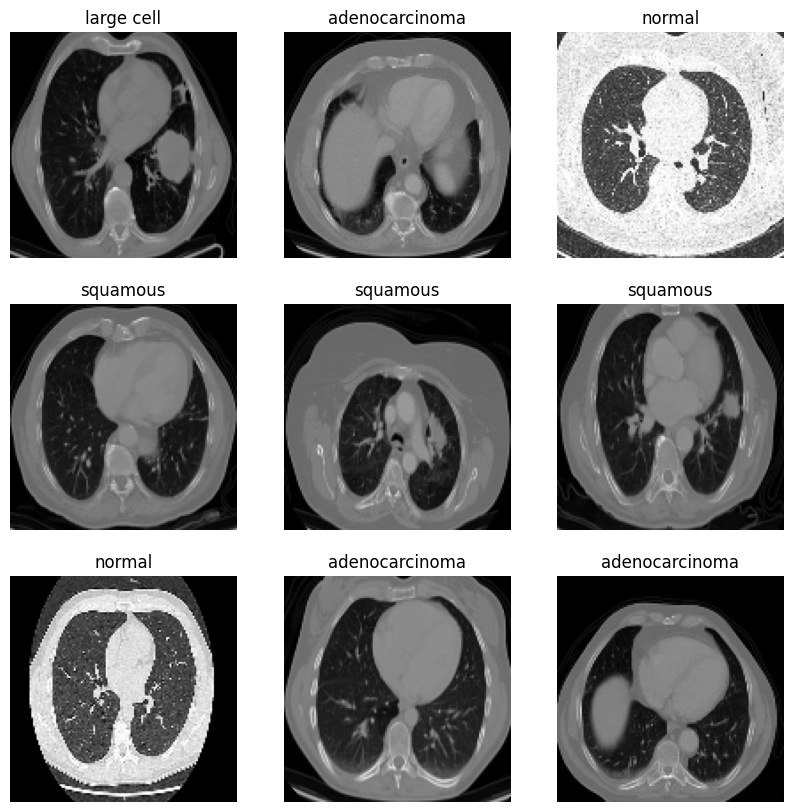

2026-04-08 10:06:37.794328: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
class_names = canonical_class_names

display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(display_names[labels[i]])
        plt.axis("off")
    plt.show()

In [13]:
print("Train batches:", tf.data.experimental.cardinality(train_data).numpy())
print("Valid batches:", tf.data.experimental.cardinality(valid_data).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_data).numpy())

Train batches: 20
Valid batches: 3
Test batches: 10


In [14]:
train_count = sum(1 for _images, labels in train_data.unbatch())
valid_count = sum(1 for _images, labels in valid_data.unbatch())
test_count = sum(1 for _images, labels in test_data.unbatch())

print("Train samples:", train_count)
print("Valid samples:", valid_count)
print("Test samples:", test_count)

Train samples: 613
Valid samples: 72
Test samples: 315


2026-04-08 10:06:38.067482: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-08 10:06:38.107969: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-08 10:06:38.230035: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
def count_images_per_class(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            counts[class_name] = len(os.listdir(class_folder))
    return counts

print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma': 90, 'large.cell.carcinoma': 51, 'adenocarcinoma': 120, 'normal': 54}


Modellering
--

Commonsense baseline
--

Vi ville ha en baseline modell som vi kan prøve å forbedre med mer avanserte modelle. Vi bruker en majoritetsklasse-modell som alltid predikerer den mest vanlige klassen i treningssettet. I koden over kan vi se at adenocarcinoma er den største klassen i treningsdata. I koden under kan vi se at adenocarcinoma er i index 0, vi kan bruke dette til å se hvilke accuracy vi kan få hvis vi kun tipper adenocarcinoma. Med denne "commonsense" modellen får vi en baseline på 38% accuracy.

In [16]:
print(class_names)

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

majority_class = 0 

y_true = []

for images, labels in test_data:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.full_like(y_true, fill_value=majority_class)

print("Baseline accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, zero_division=0))
print(confusion_matrix(y_true, y_pred))

Baseline accuracy: 0.38095238095238093
              precision    recall  f1-score   support

           0       0.38      1.00      0.55       120
           1       0.00      0.00      0.00        51
           2       0.00      0.00      0.00        54
           3       0.00      0.00      0.00        90

    accuracy                           0.38       315
   macro avg       0.10      0.25      0.14       315
weighted avg       0.15      0.38      0.21       315

[[120   0   0   0]
 [ 51   0   0   0]
 [ 54   0   0   0]
 [ 90   0   0   0]]


2026-04-08 10:06:38.380352: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Simple dens layer neural network
--

In [18]:
ff_network = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

ff_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,146,900 (12.00 MB)

 Trainable params: 3,146,900 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

ff_network summaty:
--
flatten: gjør vår input 128 * 128 * 3 om til en lang liset med tall = 49152.
første dense laget: (input_features × neurons) + bias = 3,145,792
andre dense laget: 64 * 16 + 16 = 1,040
siste dense laget: 16 * 4 + 4 = 68

In [19]:
ff_network.compile(
    loss="sparse_categorical_crossentropy", #PS: denne må kanskje endres, evt onehot encode!
    optimizer="adam",
    metrics=["accuracy"]
)

In [20]:
history_ff = ff_network.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10


2026-04-08 10:06:38.684694: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3719 - loss: 43.6447 - val_accuracy: 0.3611 - val_loss: 80.2913
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4584 - loss: 40.5665 - val_accuracy: 0.3889 - val_loss: 46.0072
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4878 - loss: 18.6281 - val_accuracy: 0.4167 - val_loss: 6.3574
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5546 - loss: 4.0545 - val_accuracy: 0.4444 - val_loss: 3.8775
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5922 - loss: 2.6967 - val_accuracy: 0.5694 - val_loss: 2.1262
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6117 - loss: 2.0064 - val_accuracy: 0.5972 - val_loss: 2.0710
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7243 - loss: 1.0118 - val_accuracy: 0.4861 - val_loss: 1.8209
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7080 - loss: 1.2254 - val_accuracy: 0.5139 - val_los

In [21]:
score = ff_network.evaluate(test_data, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 2.600688934326172
Test accuracy: 0.39047619700431824


Vi kan tydlig se at modellen vår ikke er god nok. Vi kan videre undersøke hvordan modellen fungerer.

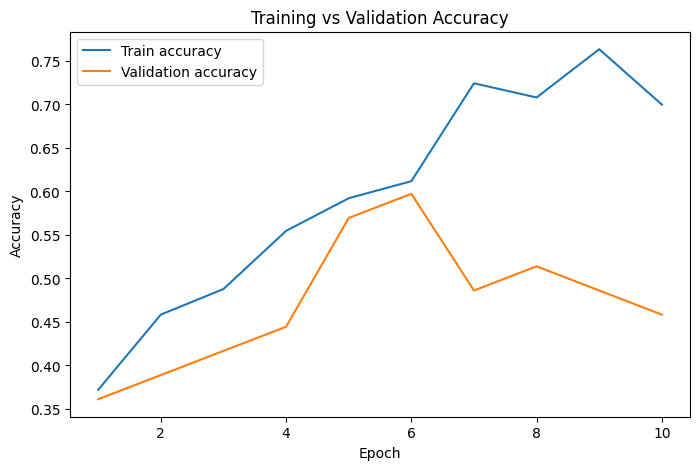

In [22]:
import matplotlib.pyplot as plt

train_acc = history_ff.history["accuracy"]
val_acc = history_ff.history["val_accuracy"]
train_loss = history_ff.history["loss"]
val_loss = history_ff.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

Tolkning av graf
--
Epoche 1-6: Begge linjene går opp => modellen lærer
Etter epoche 6: Train fortsetter opp, Validation begynner å gå ned. Dette tyder på overfitting. Modellen lærer treningsdatta godt, men klarer ikke å generalisere.
Vi kan tydlig se at modellen er best mellom epoche 5-6.

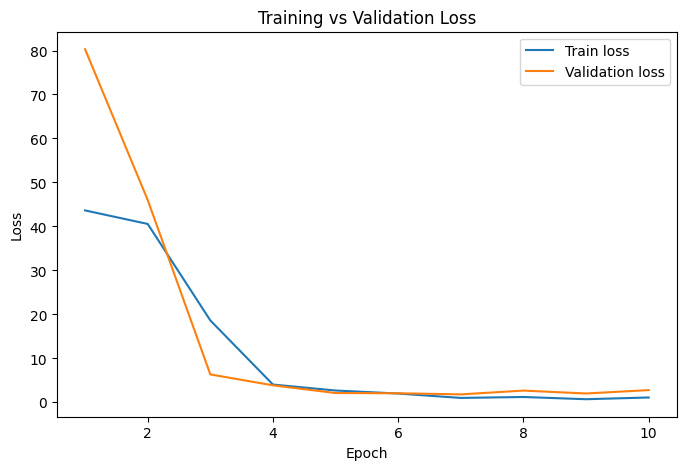

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf
--
Modellen lærer veldig fort mellom epoche 1 - 3.
mellom epoche 2-4 ligger kruvene veldig nær hverandre. modellen generaliserer bra. 
Epoche 7-10 begynner validationloss å flate ut også stige litt. Trainingloss fortsetter ganske flatt, dette kan tyde på overfitting.

2026-04-08 11:06:30.074593: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


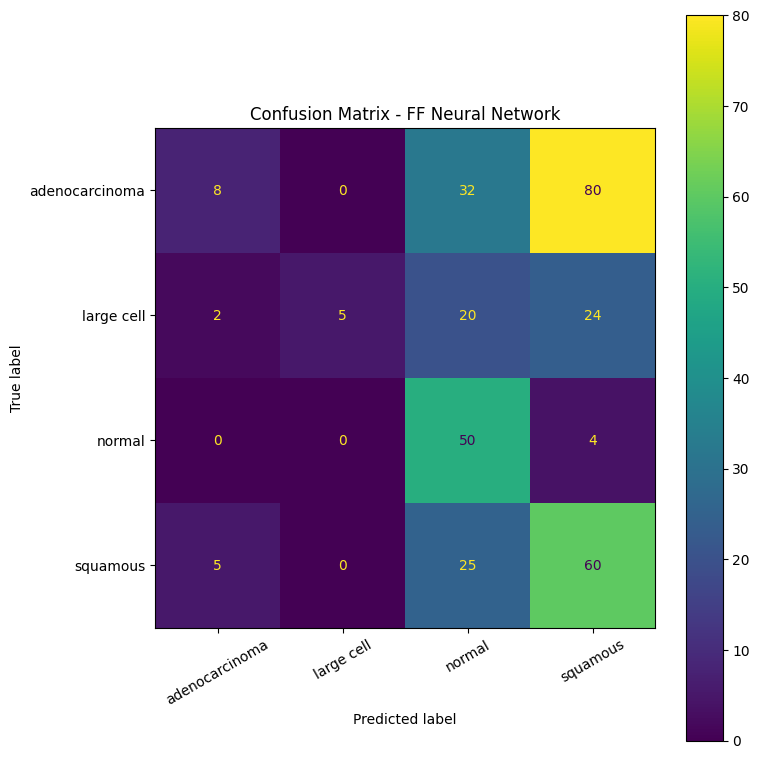

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = ff_network.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

# Korte navn som vises i figuren
display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)

plt.title("Confusion Matrix - FF Neural Network")
plt.tight_layout()
plt.show()

Data agumentation and rescaling
--

In [24]:
# Data augmentation for train-bildene
data_augmentation_ff = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

# Enkel dense-modell med augmentation
ff_network_aug = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation_ff,

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

ff_network_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,146,900 (12.00 MB)

 Trainable params: 3,146,900 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
ff_network_aug.compile(
    loss="sparse_categorical_crossentropy", #PS: denne må kanskje endres, evt onehot encode!
    optimizer="adam",
    metrics=["accuracy"]
)

In [26]:
history_ff_aug = ff_network_aug.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.2431 - loss: 115.0316 - val_accuracy: 0.3194 - val_loss: 103.9139
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2936 - loss: 135.1591 - val_accuracy: 0.3194 - val_loss: 35.5810
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2708 - loss: 92.5787 - val_accuracy: 0.2778 - val_loss: 34.9507
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2838 - loss: 96.0799 - val_accuracy: 0.3472 - val_loss: 33.8123
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2659 - loss: 86.7172 - val_accuracy: 0.3611 - val_loss: 43.1561
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2790 - loss: 92.5566 - val_accuracy: 0.2778 - val_loss: 30.2728
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2887 - loss: 78.4351 - val_accuracy: 0.2500 - val_loss: 38.4212
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3279 - loss: 69.4226 - val_ac

In [27]:
score = ff_network_aug.evaluate(test_data, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 18.715778350830078
Test accuracy: 0.4888888895511627


Prøver en CNN modell
--

In [28]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [29]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history_cnn = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=15,
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2953 - loss: 1.3565 - val_accuracy: 0.1806 - val_loss: 1.3577
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3507 - loss: 1.2944 - val_accuracy: 0.5000 - val_loss: 1.2668
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4372 - loss: 1.1904 - val_accuracy: 0.4861 - val_loss: 1.1169
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4633 - loss: 1.1089 - val_accuracy: 0.4861 - val_loss: 1.1022
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4747 - loss: 1.1252 - val_accuracy: 0.4583 - val_loss: 1.0924
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4959 - loss: 1.0771 - val_accuracy: 0.5000 - val_loss: 1.0288
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5416 - loss: 1.0209 - val_accuracy: 0.5000 - val_loss: 0.9980
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5318 - loss: 1.0213 - val_accuracy: 0.4722 - v

In [31]:
test_loss, test_acc = model.evaluate(test_data, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Test loss: 0.9744067192077637
Test accuracy: 0.5460317730903625


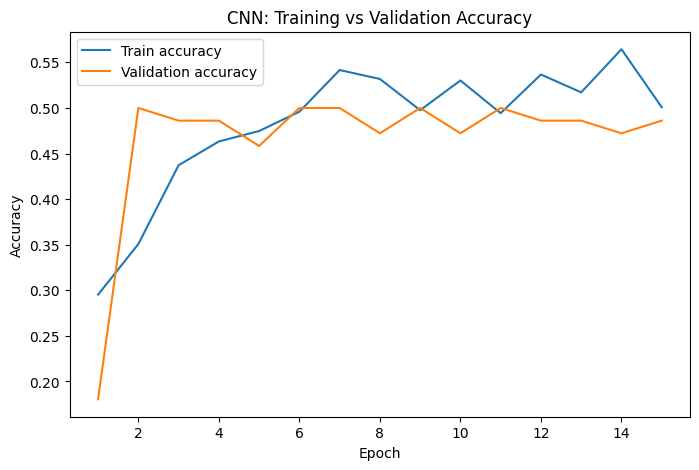

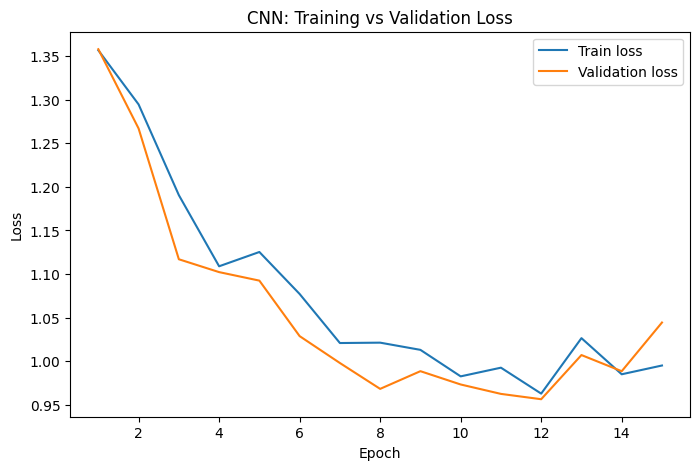

In [32]:
import matplotlib.pyplot as plt

train_acc = history_cnn.history["accuracy"]
val_acc = history_cnn.history["val_accuracy"]
train_loss = history_cnn.history["loss"]
val_loss = history_cnn.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN: Training vs Validation Loss")
plt.legend()
plt.show()

In [33]:
#overfitting^

Prøver en mer komplisert CNN
--

In [34]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])


# Modell med augmentation
augmented_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # IKKE ha med Rescaling her hvis du allerede har:
    # train_data = train_data.map(lambda x, y: (normalization_layer(x), y))

    tf.keras.layers.Conv2D(32, 3, padding="same", kernel_initializer="he_uniform"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, 3, padding="same", kernel_initializer="he_uniform"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(128, 3, padding="same", kernel_initializer="he_uniform"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(4, activation="softmax")
])

augmented_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,660 (401.02 KB)

 Trainable params: 102,212 (399.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [35]:
augmented_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [37]:
history_augmented = augmented_model.fit(
    train_data,
    epochs=20,
    validation_data=valid_data,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.4568 - loss: 1.4130 - val_accuracy: 0.1806 - val_loss: 6.0779 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.5204 - loss: 1.1472 - val_accuracy: 0.2083 - val_loss: 3.0370 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.4959 - loss: 1.2010 - val_accuracy: 0.2361 - val_loss: 1.6711 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.4829 - loss: 1.1930 - val_accuracy: 0.4444 - val_loss: 1.1373 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.5220 - loss: 1.1291 - val_accuracy: 0.4722 - val_loss: 1.0592 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5188 - loss: 1.1756 - val_accuracy: 0.4306 - val_loss: 1.1741 - learning_rate: 0.0010
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.5008 - loss: 1.2318 - val_ac

In [38]:
augmented_result = augmented_model.evaluate(test_data, verbose=0)

print("Test accuracy of the augmented model was {:.2f}%".format(augmented_result[1] * 100))

Test accuracy of the augmented model was 42.22%


In [39]:
baseline_accuracy = 0.38095238095238093  # fra baseline-modellen din

if augmented_result[1] > baseline_accuracy:
    print("Augmented model is better than baseline.")
else:
    print("Augmented model did not beat baseline.")

Augmented model is better than baseline.


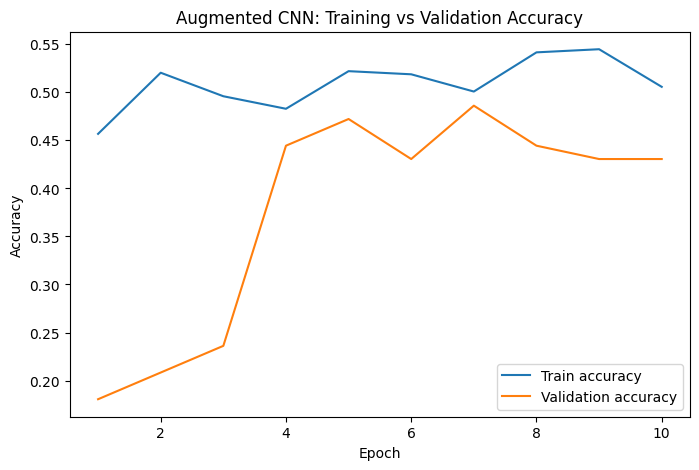

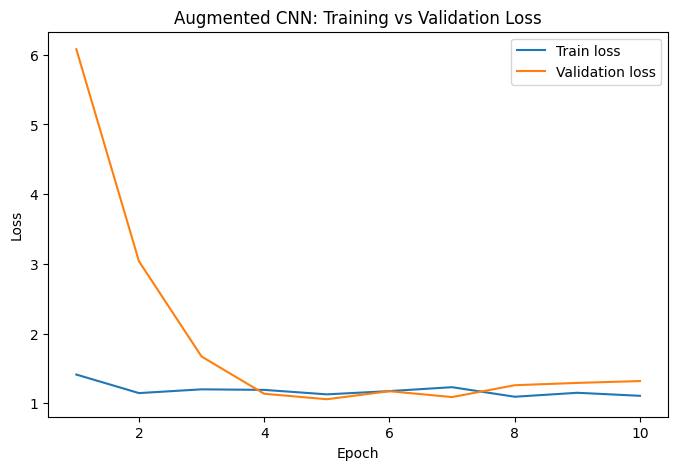

In [40]:
import matplotlib.pyplot as plt

train_acc = history_augmented.history["accuracy"]
val_acc = history_augmented.history["val_accuracy"]
train_loss = history_augmented.history["loss"]
val_loss = history_augmented.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Augmented CNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Augmented CNN: Training vs Validation Loss")
plt.legend()
plt.show()

Transfer learning
--